In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("dataset_raw.csv")

In [3]:
df.head()

,Date,Year,Month,Month_Number,MonthName,Quarter,FinancialYear,Gold_Price_USD_per_oz,Gold_Open_USD,Gold_High_USD,...,Estimated_Domestic_Gold_Price_INR_per_10g,Repo_Rate_Pct,Gold_Imports_Tonnes_Annual,Monthly_Gold_Price_Change_Pct,Monthly_USD_INR_Change_Pct,YoY_Growth_Pct,MA_3M,MA_6M,MA_12M,Rolling_Volatility_30D
0,2013-01-02,2013,1,1,January,Q1,FY12-13,1670.6,1665.2,1683.0,...,32040.24503,7.75,974.0,NaN,NaN,NaN,32040.24503,32040.24503,32040.24503,NaN
1,2013-01-03,2013,1,1,January,Q1,FY12-13,1572.3,1578.5,1586.9,...,30282.85372,7.75,974.0,NaN,NaN,NaN,31161.54937,31161.54937,31161.54937,NaN
2,2013-01-04,2013,1,1,January,Q1,FY12-13,1600.9,1598.1,1601.6,...,31099.79676,7.75,974.0,NaN,NaN,NaN,31140.96517,31140.96517,31140.96517,5.446918
3,2013-01-05,2013,1,1,January,Q1,FY12-13,1446.2,1475.6,1477.4,...,28094.52563,7.75,974.0,NaN,NaN,NaN,30379.35528,30379.35528,30379.35528,5.851831
4,2013-01-07,2013,1,1,January,Q1,FY12-13,1255.7,1232.9,1261.7,...,24513.69167,7.75,974.0,NaN,NaN,NaN,29206.22256,29206.22256,29206.22256,6.426772


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3085 entries, 0 to 3084
Data columns (total 30 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Date                                       3085 non-null   object 
 1   Year                                       3085 non-null   int64  
 2   Month                                      3085 non-null   int64  
 3   Month_Number                               3085 non-null   int64  
 4   MonthName                                  3085 non-null   object 
 5   Quarter                                    3085 non-null   object 
 6   FinancialYear                              3085 non-null   object 
 7   Gold_Price_USD_per_oz                      3085 non-null   float64
 8   Gold_Open_USD                              3085 non-null   float64
 9   Gold_High_USD                              3085 non-null   float64
 10  Gold_Low_USD            

In [5]:
df.isnull().sum()

Date                                           0
Year                                           0
Month                                          0
Month_Number                                   0
MonthName                                      0
Quarter                                        0
FinancialYear                                  0
Gold_Price_USD_per_oz                          0
Gold_Open_USD                                  0
Gold_High_USD                                  0
Gold_Low_USD                                   0
Gold_Daily_Change_Pct                          0
USD_INR_Rate                                   0
Gold_Price_INR_per_oz                          0
Gold_Price_INR_per_10g                         0
Import_Duty_Rate_Pct                           0
Import_Duty_Amount_INR_per_10g                 0
GST_Rate_Pct                                   0
GST_Amount_INR_per_10g                         0
Price_Plus_Duty_INR_per_10g                    0
Estimated_Domestic_G

In [6]:
df = f.fillna(0)

NameError: name 'f' is not defined

In [37]:
df["Date"] = pd.to_datetime(df["Date"])

In [38]:
df.dtypes

Date                                         datetime64[ns]
Year                                                  int64
Month                                                 int64
Month_Number                                          int64
MonthName                                            object
Quarter                                              object
FinancialYear                                        object
Gold_Price_USD_per_oz                               float64
Gold_Open_USD                                       float64
Gold_High_USD                                       float64
Gold_Low_USD                                        float64
Gold_Daily_Change_Pct                               float64
USD_INR_Rate                                        float64
Gold_Price_INR_per_oz                               float64
Gold_Price_INR_per_10g                              float64
Import_Duty_Rate_Pct                                float64
Import_Duty_Amount_INR_per_10g          

In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
df.shape

(3085, 30)

In [41]:
df.to_csv("dataset_cleaned(1).csv")

## DAY 12

### EXPLORATORY DATA ANALYSIS (E

#### SUMMARY STATS

In [42]:
df[["Gold_Price_USD_per_oz","Gold_Open_USD","Gold_High_USD"]].describe()

,Gold_Price_USD_per_oz,Gold_Open_USD,Gold_High_USD
count,3085.00000,3085.000000,3085.000000
mean,1815.46800,1815.554318,1830.195634
std,866.78761,866.747897,878.933259
min,1049.60000,1051.500000,1062.700000
25%,1268.40000,1268.000000,1276.800000
50%,1523.60000,1526.600000,1542.800000
75%,1915.40000,1916.700000,1929.400000
max,5354.80000,5449.900000,5626.800000


#### DISTRIBUTION

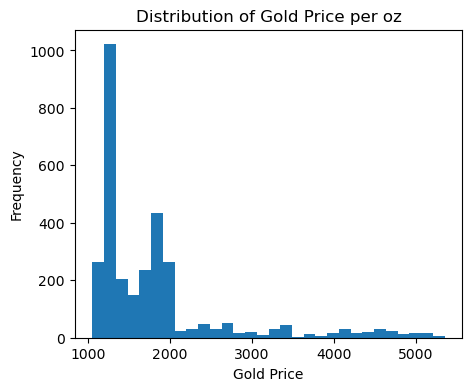

In [43]:
# GOLD PRICE

import matplotlib.pyplot as plt
plt.figure(figsize=(5,4))
plt.hist(df["Gold_Price_USD_per_oz"], bins=30)
plt.title("Distribution of Gold Price per oz")
plt.xlabel("Gold Price")
plt.ylabel("Frequency")
plt.show()

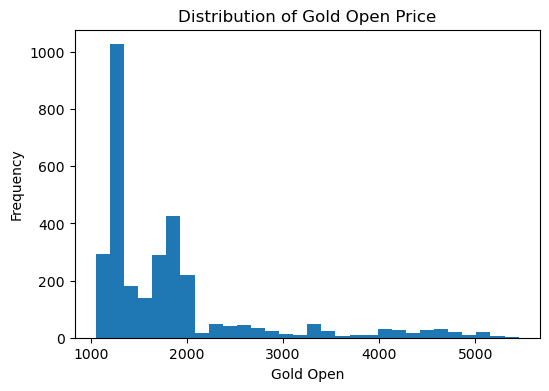

In [44]:
# GOLD OPEN
plt.figure(figsize=(6,4))
plt.hist(df["Gold_Open_USD"], bins=30)
plt.title("Distribution of Gold Open Price")
plt.xlabel("Gold Open")
plt.ylabel("Frequency")
plt.show()

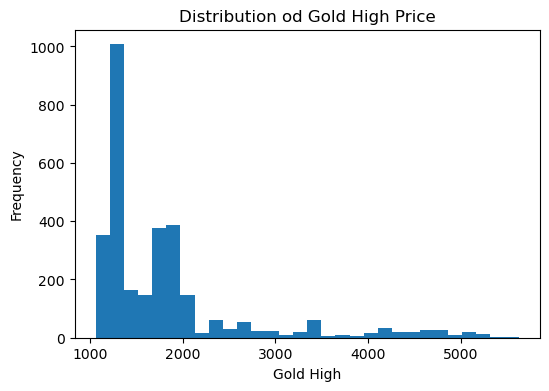

In [45]:
# GOLD HIGJ

plt.figure(figsize=(6,4))
plt.hist(df["Gold_High_USD"], bins=30)
plt.title("Distribution od Gold High Price")
plt.xlabel("Gold High")
plt.ylabel("Frequency")
plt.show()

#### SEGMENT BY QUARTER



In [46]:
df.groupby("Quarter")[ ["Gold_Price_USD_per_oz", "Gold_Open_USD", "Gold_High_USD"]].mean()

,Gold_Price_USD_per_oz,Gold_Open_USD,Gold_High_USD
Quarter,,,
Q1,1913.495082,1913.701454,1931.212086
Q2,1903.291967,1903.980799,1919.641650
Q3,1726.140182,1726.186411,1738.284395
Q4,1709.563501,1708.918589,1722.044030


#### SEGMENT BY MonthName

In [47]:
df.groupby("MonthName")["Gold_Price_USD_per_oz"].mean()

MonthName
April        1933.788846
August       1699.089883
December     1694.247436
February     1942.516138
January      1895.536479
July         1776.000375
June         1880.798092
March        1905.062590
May          1895.638609
November     1694.365702
October      1737.386590
September    1700.177959
Name: Gold_Price_USD_per_oz, dtype: float64

#### SEGMENT BY FinancialYear

In [48]:
df.groupby("FinancialYear")["Gold_Price_USD_per_oz"].mean()

FinancialYear
FY12-13    1545.545763
FY13-14    1346.630588
FY14-15    1244.792829
FY15-16    1163.516000
FY16-17    1255.792430
FY17-18    1277.199010
FY18-19    1278.080905
FY19-20    1488.828704
FY20-21    1813.483465
FY21-22    1813.780392
FY22-23    1819.252217
FY23-24    2013.458081
FY24-25    2625.750251
FY25-26    3953.991689
FY26-27    4515.343243
Name: Gold_Price_USD_per_oz, dtype: float64

#### DAY AND DAY_NAME FROM YEAR

In [49]:
df["Derived_Day"] = df["Date"].dt.day

In [50]:
df["Derived_DayName"] = df["Date"].dt.day_name()

In [51]:
df[[
    "Derived_Day",
    "Derived_DayName"
]].head()

,Derived_Day,Derived_DayName
0,2,Wednesday
1,3,Thursday
2,4,Friday
3,5,Saturday
4,7,Monday


## DAY 13

### OUTLIER ANALYSIS

In [18]:
# Gold Price per oz

Q1 = df["Gold_Price_USD_per_oz"].quantile(0.25)
Q3 = df["Gold_Price_USD_per_oz"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df["Gold_Price_USD_per_oz"] < lower) |
              (df["Gold_Price_USD_per_oz"] > upper)]
print(len(outliers))

323


In [19]:
# Gold Price Open

Q1 = df["Gold_Open_USD"].quantile(0.25)
Q3 = df["Gold_Open_USD"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df["Gold_Open_USD"] < lower) |
              (df["Gold_Open_USD"] > upper)]
print(len(outliers))


320


In [20]:
# Gold Price High

Q1 = df["Gold_High_USD"].quantile(0.25)
Q3 = df["Gold_High_USD"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df["Gold_High_USD"] < lower) |
              (df["Gold_High_USD"] > upper)]
print(len(outliers))


321


### CHARTS

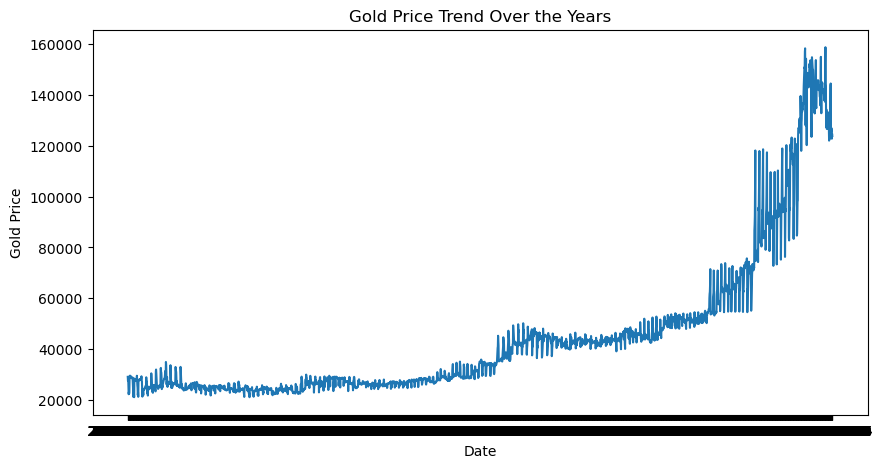

In [21]:
plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Gold_Price_INR_per_10g"])
plt.title("Gold Price Trend Over the Years")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.show()

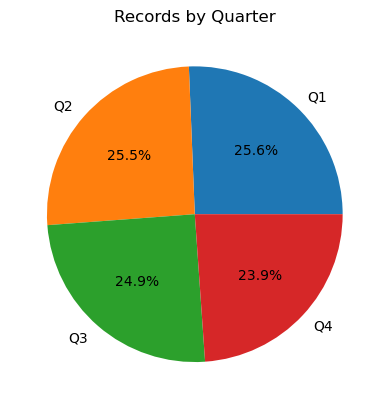

In [22]:
quarter = df["Quarter"].value_counts()
plt.pie(quarter,labels=quarter.index,autopct="%1.1f%%")
plt.title("Records by Quarter")
plt.show()

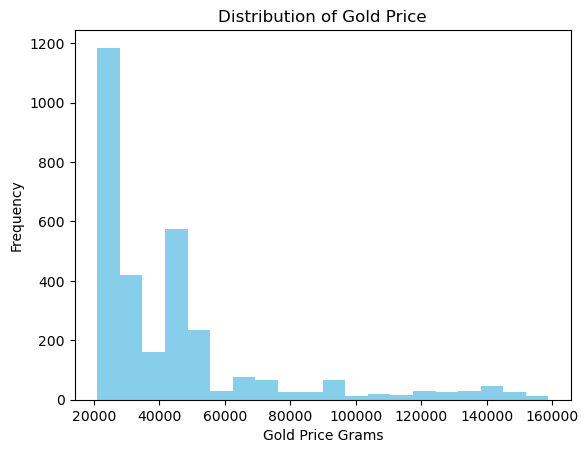

In [23]:
plt.hist(df["Gold_Price_INR_per_10g"], bins=20 , color = "skyblue")
plt.title("Distribution of Gold Price")
plt.xlabel("Gold Price Grams")
plt.ylabel("Frequency")
plt.show()

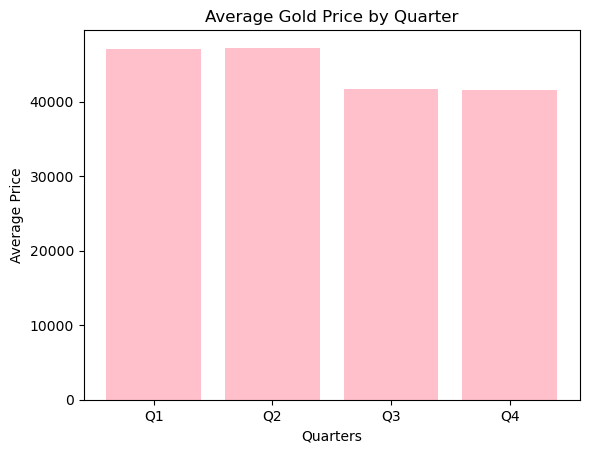

In [24]:
quarter = df.groupby("Quarter")["Gold_Price_INR_per_10g"].mean()
plt.bar(quarter.index, quarter.values , color ="pink")
plt.title("Average Gold Price by Quarter")
plt.xlabel("Quarters")
plt.ylabel("Average Price")
plt.show()

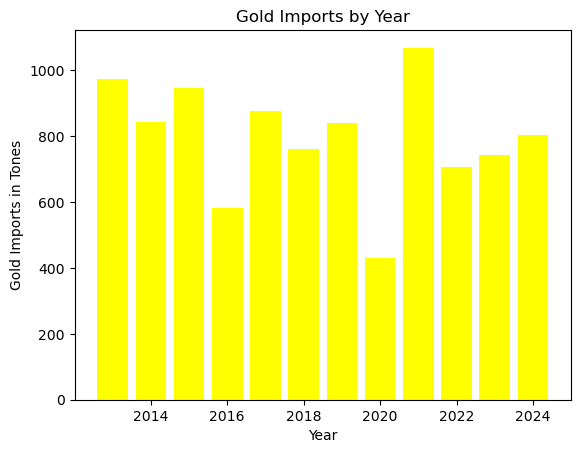

In [25]:
imports = df.groupby("Year")["Gold_Imports_Tonnes_Annual"].mean()
plt.bar(imports.index, imports.values, color="yellow")
plt.title("Gold Imports by Year")
plt.xlabel("Year")
plt.ylabel("Gold Imports in Tones")
plt.show()

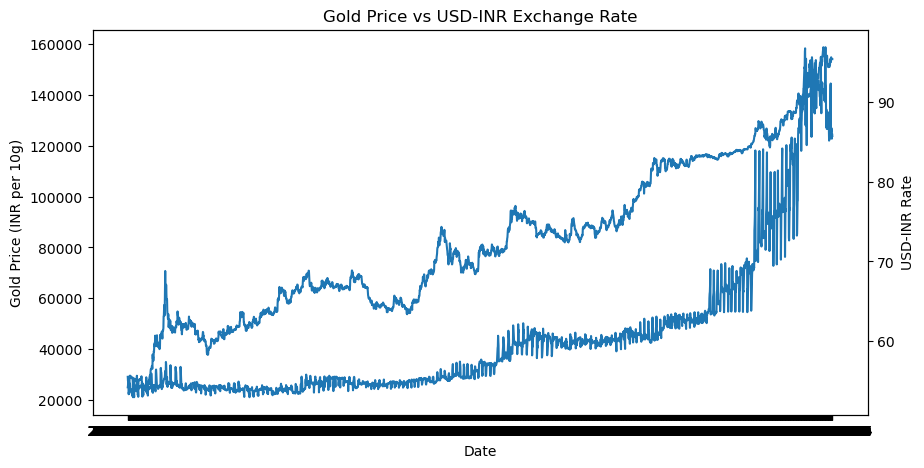

In [26]:
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(df["Date"], df["Gold_Price_INR_per_10g"])
ax1.set_ylabel("Gold Price (INR per 10g)")
ax1.set_xlabel("Date")
ax2 = ax1.twinx()
ax2.plot(df["Date"], df["USD_INR_Rate"])
ax2.set_ylabel("USD-INR Rate")
plt.title("Gold Price vs USD-INR Exchange Rate")
plt.show()

#### Gold Price has Significantly Increased Over the Years(2013-26)
#### We can see that there is a sudden increase in gold prices after from 2024

## DAY 14

#### DESCRIPTIVE STATS

In [27]:
df[["Gold_Price_USD_per_oz", "Gold_Open_USD", "Gold_High_USD"]].describe()

,Gold_Price_USD_per_oz,Gold_Open_USD,Gold_High_USD
count,3085.00000,3085.000000,3085.000000
mean,1815.46800,1815.554318,1830.195634
std,866.78761,866.747897,878.933259
min,1049.60000,1051.500000,1062.700000
25%,1268.40000,1268.000000,1276.800000
50%,1523.60000,1526.600000,1542.800000
75%,1915.40000,1916.700000,1929.400000
max,5354.80000,5449.900000,5626.800000


#### DISTRIBUTION ANALYSIS - Already performed above

#### SKEWNESS

In [28]:
print(df["Gold_Price_USD_per_oz"].skew())

2.1469486018073174


In [29]:
print(df["Gold_Open_USD"].skew())

2.151519682669083


In [30]:
print(df["Gold_High_USD"].skew())

2.1665867066165676


#### KURTOSIS

In [31]:
print(df["Gold_Price_USD_per_oz"].kurt())

4.224652127755245


In [32]:
print(df["Gold_Open_USD"].kurt())

4.258958875505064


In [33]:
print(df["Gold_High_USD"].kurt())

4.3356393690106545


##### The dataset contains historical gold price data from 2013 to 2026, so the results describe past market behavior.
##### Gold prices are influenced by external factors also  such as USD-INR exchange rates, inflation etc.
##### In the Recent Years the gold prices have increased , which can affect mean, variance, skewness, and kurtosis.
##### Extreme values may represent genuine market movements and should not automatically be treated as errors.


## DAY 15

#### CORRELATION MATRIX

In [52]:
col_mat = [ "Gold_Price_USD_per_oz","Gold_Open_USD","Gold_High_USD"]
correlation = df[col_mat].corr()
print(correlation)

                       Gold_Price_USD_per_oz  Gold_Open_USD  Gold_High_USD
Gold_Price_USD_per_oz               1.000000       0.999514       0.999699
Gold_Open_USD                       0.999514       1.000000       0.999826
Gold_High_USD                       0.999699       0.999826       1.000000


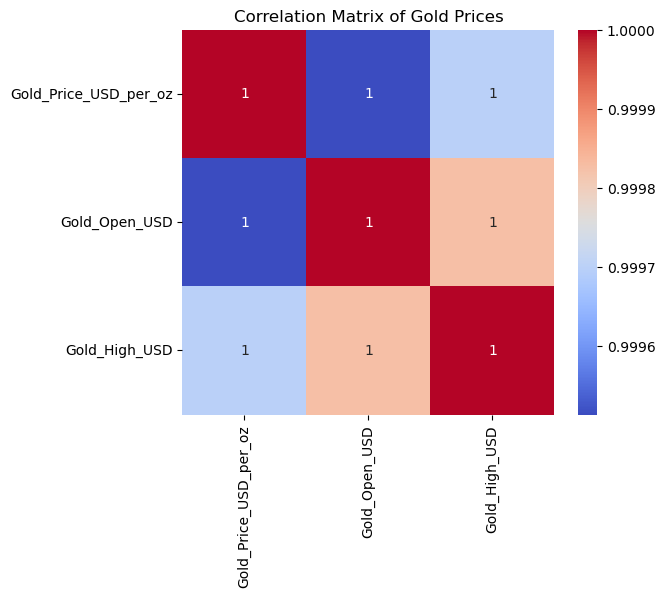

In [55]:
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Gold Prices")
plt.show()

#### VARIANCE ANALYSIS

In [56]:
#Month Number
variance_month = df.groupby("Month_Number")["Gold_Price_USD_per_oz"].var()
print(variance_month)

Month_Number
1     9.987693e+05
2     1.149980e+06
3     9.924169e+05
4     1.028551e+06
5     9.100480e+05
6     8.650379e+05
7     5.717882e+05
8     3.616604e+05
9     4.296977e+05
10    5.487584e+05
11    4.764318e+05
12    5.334141e+05
Name: Gold_Price_USD_per_oz, dtype: float64


In [58]:
# Month Name
variance_monthname = df.groupby("MonthName")["Gold_Price_USD_per_oz"].var()
print(variance_monthname)

MonthName
April        1.028551e+06
August       3.616604e+05
December     5.334141e+05
February     1.149980e+06
January      9.987693e+05
July         5.717882e+05
June         8.650379e+05
March        9.924169e+05
May          9.100480e+05
November     4.764318e+05
October      5.487584e+05
September    4.296977e+05
Name: Gold_Price_USD_per_oz, dtype: float64


In [60]:
# Quarter
variance_quarter = df.groupby("Quarter")["Gold_Price_USD_per_oz"].var()
print(variance_quarter)

Quarter
Q1    1.041304e+06
Q2    9.323028e+05
Q3    4.564374e+05
Q4    5.191516e+05
Name: Gold_Price_USD_per_oz, dtype: float64


#### Hypothesis

##### Null Hypothesis: let as assume there is no strong relationship between Gold Open Price and Gold Price.
##### Alternative Hypothesis: There is a strong positive relationship between Gold Open and Gold Price.

In [66]:
Corr = df["Gold_Price_USD_per_oz"].corr(df["Gold_Open_USD"])
print(Corr)

0.9995136575502055


#### The Correlation is very close to 1, so we can tell that it has a very strong positive relationship between Gold open and gold price. The data supports alternative hypothesis.

#### The dataset contains historical gold prices from 2013–2026.
#### Gold prices are affected by external factors such as USD-INR exchange rates, inflation etc.
#### The strong correlation between the price variables does not imply causation.
#### Extreme price movements can influence variance and correlation.
#### The analysis is based only on the available observations in the dataset.


### DAY 16